# Summer School UPC
## Febrero 2026

# Análisis Inteligente de Datos


## Docente: PhD. Débora Chan

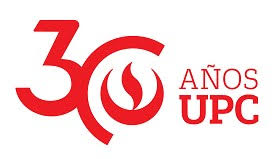

<h2 style="color:darkcyan;">Para el primer ejemplo vamos a utilizar los datos del titanic</h2>

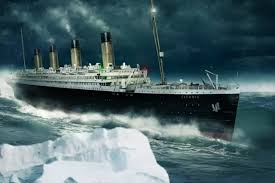

**PassengerId**: Identificador único para cada pasajero

**Survived**: Estado de supervivencia (0 = murió, 1 = sobrevivió)

**Pclass**: Clase de billete (1 = primera clase, 2 = segunda clase, 3 = tercera clase)

**sex**: Género (masculino o femenino)

**age**: Edad del pasajero

**sibSp**: Número de hermanos o cónyuges a bordo

**parch**: Número de padres o hijos a bordo

**class**: clase en que viaja

**fare**: Tarifa del billete

**deck**: Número de cabaña

**embarked** : Puerto de embarque (C = Cherburgo, Q = Queenstown, S = Southampton)

**alive**: sobrevida en texto.

**alone**: si viaja solo o no.

In [5]:
#Se importan la librerias a utilizar
import seaborn as sns
import pandas as pd
import matplotlib as plt
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# importando dataset
import seaborn as sns
titanic = sns.load_dataset('titanic')




In [6]:
# ver primeros 10 registros
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


<h2 style="color:darkred;">Tabla de frecuencia de clases de pasajeros</h2>

In [4]:

pd.value_counts(titanic['class'])

Third     491
First     216
Second    184
Name: class, dtype: int64

<h2 style="color:darkred;">Tabla de frecuencia relativa de pasajeros</h2>

In [8]:

(100 * titanic['class'].value_counts() / len(titanic['class'])).round(3)

class
Third     55.107
First     24.242
Second    20.651
Name: count, dtype: float64

<h2 style="color:darkred;"> Gráfico de barras de pasajeros del Titanic por clase</h2>

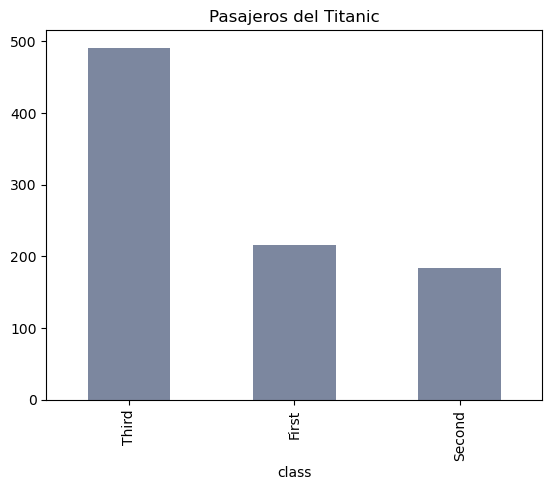

In [15]:

plot = titanic['class'].value_counts().plot(kind='bar',
                                            title='Pasajeros del Titanic',color="#445577",alpha=0.7)

<h2 style="color:darkred;"> Gráfico de tarta de pasajeros del Titanic por clase</h2>

Text(0, 0.5, '')

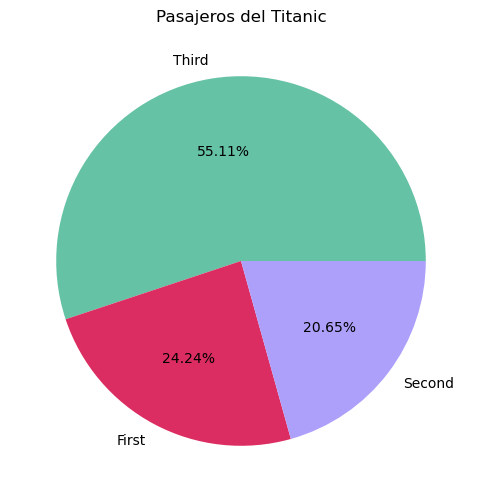

In [23]:

colors = ['#66c2a5', '#dc2d62', '#ada0fb']  # ejemplo (ajustá cantidad)

plot = titanic['class'].value_counts().plot(
    kind='pie',
    autopct='%.2f%%',
    figsize=(6, 6),
    title='Pasajeros del Titanic',
    colors=colors
)
plot.set_ylabel('')  # opcional: saca el "class" al costado

<h2 style="color:darkred;"> Tabla de contingencia class / survived</h2>

In [11]:

pd.crosstab(index=titanic['survived'],
            columns=titanic['class'], margins=True)

class,First,Second,Third,All
survived,,,,
0,80,97,372,549
1,136,87,119,342
All,216,184,491,891


<h2 style="color:darkred;"> Tabla de contingencia en porcentajes relativos total clase- sobrevida </h2>

In [24]:

pd.crosstab(index=titanic['survived'], columns=titanic['class'],
            margins=True).apply(lambda r: r/len(titanic) *100,
                                axis=1)

class,First,Second,Third,All
survived,,,,
0,8.978676,10.886644,41.750842,61.616162
1,15.263749,9.764310,13.355780,38.383838
All,24.242424,20.650954,55.106622,100.000000


<h2 style="color:darkred;"> Gráfico de barras de sobreviviviente segun clase </h2>

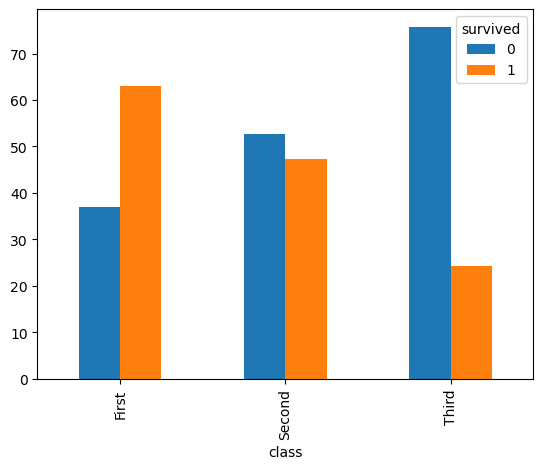

In [29]:

plot = pd.crosstab(index=titanic['class'],
            columns=titanic['survived']).apply(lambda r: r/r.sum() *100,
                                              axis=1).plot(kind='bar')

<h2 style="color:darkred;"> Gráfico de barras de sobreviviviente segun clase </h2>

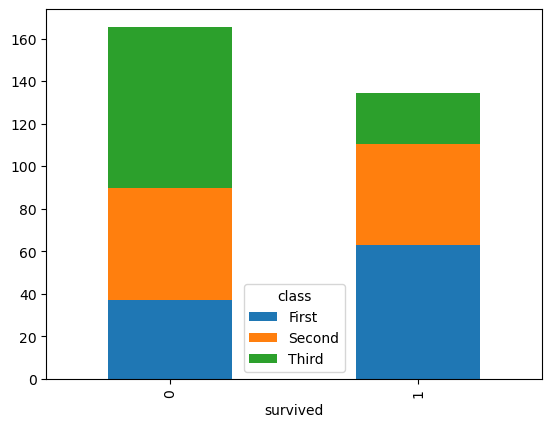

In [30]:

plot = pd.crosstab(index=titanic['survived'],
            columns=titanic['class']
                  ).apply(lambda r: r/r.sum() *100,
                          axis=0).plot(kind='bar', stacked=True)

<h3 style="color:darkgreen;"> Contraste de Independencia de Pearson </h3>

In [32]:
import scipy as sp
import numpy as np
contingency_table=pd.crosstab(index=titanic['survived'],
            columns=titanic['class'], margins=False)
sp.stats.chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=102.88898875696056, pvalue=4.549251711298793e-23, dof=2, expected_freq=array([[133.09090909, 113.37373737, 302.53535354],
       [ 82.90909091,  70.62626263, 188.46464646]]))

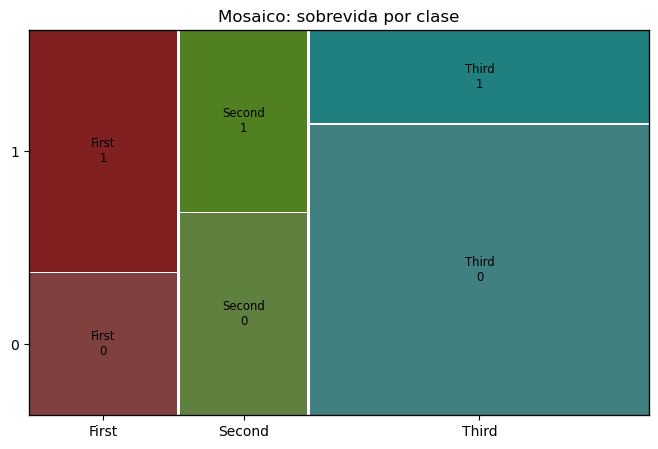

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

# clase primero (ancho), sobrevivió dentro (alto)
contingency_table = pd.crosstab(titanic['class'], titanic['survived'])
data = contingency_table.stack().to_dict()

fig, ax = plt.subplots(figsize=(8,5))
mosaic(data, ax=ax)
ax.set_title("Mosaico: sobrevida por clase")
plt.show()



In [40]:
#!python -m pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 6.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2


In [50]:
!pip install mca


<h1 style="color:darkcyan;"> Análisis de Correspondencias Simples </h1>



In [60]:
import pandas as pd
import prince
from IPython.display import display

def ca_2d(df, row, col):
    tab = pd.crosstab(df[row], df[col])

    max_dim = min(tab.shape[0]-1, tab.shape[1]-1)
    if max_dim < 2:
        raise ValueError(f"Esta tabla es {tab.shape} y no permite CA en 2D (solo {max_dim} dimensión).")

    ca = prince.CA(
        n_components=2,
        n_iter=10,
        copy=True,
        check_input=True,
        engine="sklearn",
        random_state=42
    ).fit(tab)

    chart = ca.plot(
        tab,
        x_component=0, y_component=1,
        show_row_markers=True,
        show_column_markers=True,
        show_row_labels=True,
        show_column_labels=True
    )
    return tab, ca, chart


<h2 style="color:darkcyan;"> CA survived-class </h2>

In [63]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*convert_dtype parameter is deprecated.*",
    category=FutureWarning
)

In [65]:
import pandas as pd
import prince
from IPython.display import display

# Tabla de contingencia 3x3
tab = pd.crosstab(t["embarked"], t["class"])
display(tab)

# CA 2D
ca = prince.CA(
    n_components=2,
    n_iter=10,
    engine="sklearn",
    random_state=42
).fit(tab)

chart = ca.plot(
    tab,
    x_component=0, y_component=1,
    show_row_markers=True,
    show_column_markers=True,
    show_row_labels=True,
    show_column_labels=True
)


import altair as alt

# tu chart existente:
# chart = ca.plot(tab, x_component=0, y_component=1, ...)

# líneas de ejes
x0 = alt.Chart(pd.DataFrame({"x":[0]})).mark_rule().encode(x="x:Q")
y0 = alt.Chart(pd.DataFrame({"y":[0]})).mark_rule().encode(y="y:Q")

display(chart + x0 + y0)







class,First,Second,Third
embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


alt.LayerChart(...)

<h3 style="color:darkcyan;"> Importancia de Categorías en ambas Variables </h3>

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# coordenadas de categorías (filas = embarked; columnas = class)
rows = ca.row_coordinates(tab)      # Dim0 y Dim1
cols = ca.column_coordinates(tab)

# distancia al origen (más lejos = más "importante" en el plano)
rows_imp = pd.Series(np.sqrt(rows[0]**2 + rows[1]**2), index=rows.index, name="importancia")
cols_imp = pd.Series(np.sqrt(cols[0]**2 + cols[1]**2), index=cols.index, name="importancia")

# unimos en una tabla
imp = pd.concat([
    rows_imp.rename("importancia").to_frame().assign(tipo="Embarked"),
    cols_imp.rename("importancia").to_frame().assign(tipo="Class")
]).reset_index().rename(columns={"index":"categoria"})

display(imp.sort_values("importancia", ascending=False))


,categoria,importancia,tipo
1,Q,0.770208,Embarked
0,C,0.626370,Embarked
3,First,0.567473,Class
4,Second,0.380643,Class
5,Third,0.239563,Class
2,S,0.137417,Embarked


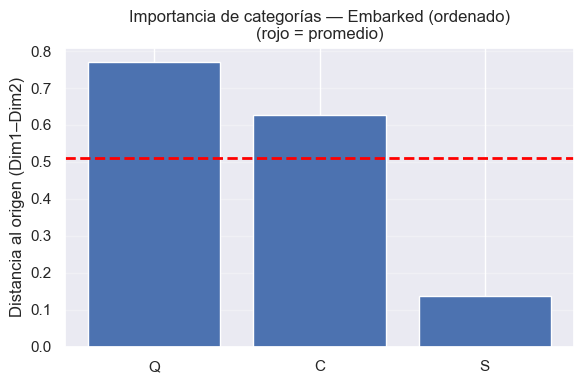

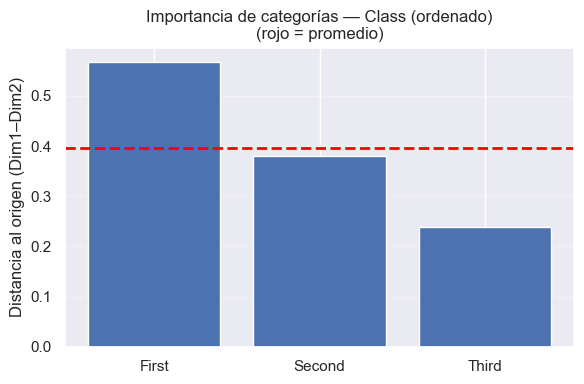

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importancia = distancia al origen
rows_imp = pd.Series(np.sqrt(rows[0]**2 + rows[1]**2), index=rows.index).sort_values(ascending=False)
cols_imp = pd.Series(np.sqrt(cols[0]**2 + cols[1]**2), index=cols.index).sort_values(ascending=False)

# --- Embarked ---
prom_e = rows_imp.mean()

plt.figure(figsize=(6,4))
plt.bar(rows_imp.index.astype(str), rows_imp.values)
plt.axhline(prom_e, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distancia al origen (Dim1–Dim2)")
plt.title("Importancia de categorías — Embarked (ordenado)\n(rojo = promedio)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Class ---
prom_c = cols_imp.mean()

plt.figure(figsize=(6,4))
plt.bar(cols_imp.index.astype(str), cols_imp.values)
plt.axhline(prom_c, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distancia al origen (Dim1–Dim2)")
plt.title("Importancia de categorías — Class (ordenado)\n(rojo = promedio)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


<h3 style="color:darkcyan;">Ejemplo de Niveles de Atención versus niveles socioculturales</h3>

## Cargamos los datos

In [81]:
import pandas as pd

tab = pd.DataFrame(
    {
        "A": [64, 94, 58, 46],
        "B": [57, 94, 54, 40],
        "C": [57,105, 65, 60],
        "D": [72,141, 77, 94],
        "E": [36, 97, 54, 78],
        "F": [21, 51, 34, 51],
    },
    index=["Atento", "Sínt. leves", "Sínt. moderados", "Disperso"]
)

tab


,A,B,C,D,E,F
Atento,64,57,57,72,36,21
Sínt. leves,94,94,105,141,97,51
Sínt. moderados,58,54,65,77,54,34
Disperso,46,40,60,94,78,51


## Realizamos y graficamos el AC y el mapa perceptual o biplot simétrico

In [82]:
import prince
from IPython.display import display

ca = prince.CA(n_components=2, engine="sklearn", random_state=42).fit(tab)

chart = ca.plot(
    tab,
    x_component=0, y_component=1,
    show_row_labels=True, show_column_labels=True,
    show_row_markers=True, show_column_markers=True
)

display(chart)


alt.LayerChart(...)

## Inspeccionamos la importancia de variables

In [83]:
import numpy as np
import matplotlib.pyplot as plt

rows = ca.row_coordinates(tab)      # coordenadas filas (atención)
cols = ca.column_coordinates(tab)   # coordenadas columnas (sociocultural)

# Distancia al origen (más lejos = más "importante" en el plano)
rows_imp = pd.Series(np.sqrt(rows[0]**2 + rows[1]**2), index=rows.index).sort_values(ascending=False)
cols_imp = pd.Series(np.sqrt(cols[0]**2 + cols[1]**2), index=cols.index).sort_values(ascending=False)


## Graficamos contribuciones por fila

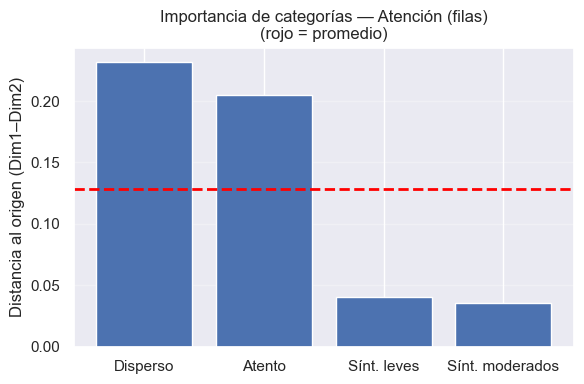

In [84]:
prom_rows = rows_imp.mean()

plt.figure(figsize=(6,4))
plt.bar(rows_imp.index.astype(str), rows_imp.values)
plt.axhline(prom_rows, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distancia al origen (Dim1–Dim2)")
plt.title("Importancia de categorías — Atención (filas)\n(rojo = promedio)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Graficamos contribuciones a la inercia por columna

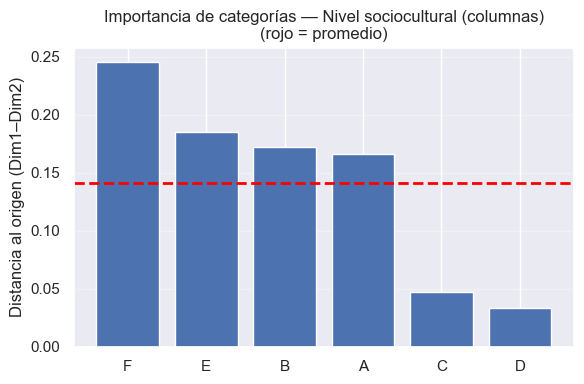

In [85]:
prom_cols = cols_imp.mean()

plt.figure(figsize=(6,4))
plt.bar(cols_imp.index.astype(str), cols_imp.values)
plt.axhline(prom_cols, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distancia al origen (Dim1–Dim2)")
plt.title("Importancia de categorías — Nivel sociocultural (columnas)\n(rojo = promedio)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [87]:
## Heatmap para ver las contribuciones por celda

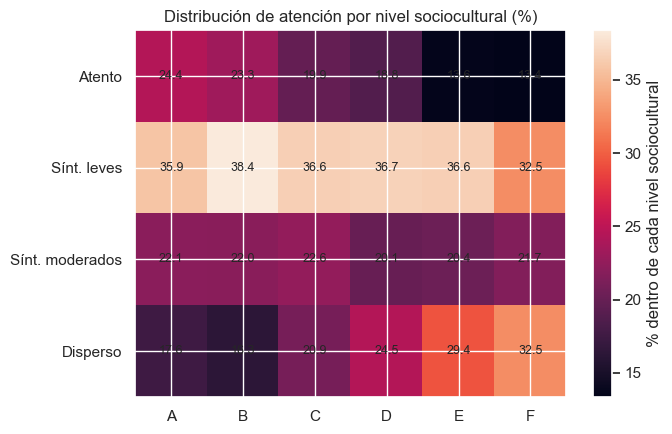

In [86]:
import numpy as np
import matplotlib.pyplot as plt

prop_col = tab.div(tab.sum(axis=0), axis=1) * 100  # % dentro de cada columna

plt.figure(figsize=(7,4.5))
plt.imshow(prop_col.values, aspect='auto')
plt.colorbar(label='% dentro de cada nivel sociocultural')
plt.xticks(range(prop_col.shape[1]), prop_col.columns)
plt.yticks(range(prop_col.shape[0]), prop_col.index)
plt.title("Distribución de atención por nivel sociocultural (%)")

# escribir los porcentajes en cada celda
for i in range(prop_col.shape[0]):
    for j in range(prop_col.shape[1]):
        plt.text(j, i, f"{prop_col.iloc[i,j]:.1f}", ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()


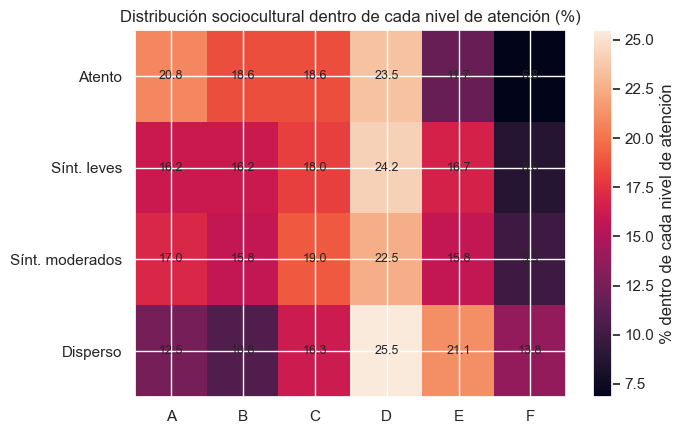

In [88]:
prop_row = tab.div(tab.sum(axis=1), axis=0) * 100  # % dentro de cada fila

plt.figure(figsize=(7,4.5))
plt.imshow(prop_row.values, aspect='auto')
plt.colorbar(label='% dentro de cada nivel de atención')
plt.xticks(range(prop_row.shape[1]), prop_row.columns)
plt.yticks(range(prop_row.shape[0]), prop_row.index)
plt.title("Distribución sociocultural dentro de cada nivel de atención (%)")

for i in range(prop_row.shape[0]):
    for j in range(prop_row.shape[1]):
        plt.text(j, i, f"{prop_row.iloc[i,j]:.1f}", ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()


# MCA

Los datos “admi” del paquete FactoClass, que son los estudiantes admitidos a las 7 carreras de la Facultad de ciencias de la Universidad Nacional de Colombia (Bogotá) en el primer trimestre del 2013. Estos datos poseen información de los puntajes obtenidos por estos estudiantes (445 admitidos) en el examen de ingreso, así como también algunas variables de información sociodemográfica.

In [93]:
import prince
import pandas as pd

admi = pd.read_csv("C:/Users/Debora/Dropbox/CursoUPC/datos/admi.csv")
X = admi[["carr", "gene", "estr", "orig", "Age"]].dropna()
mca = prince.MCA(
    n_components=2,
    n_iter=10,
    engine="sklearn",
    random_state=42
).fit(X)



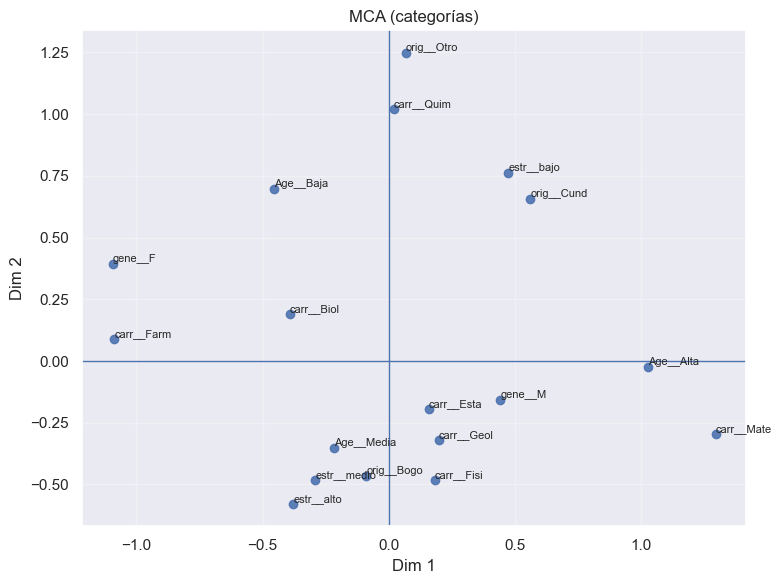

In [94]:
import matplotlib.pyplot as plt

# Coordenadas de categorías (column points)
cat_coords = mca.column_coordinates(X)   # filas = categorías, cols = [0,1]

plt.figure(figsize=(8,6))
plt.scatter(cat_coords[0], cat_coords[1], alpha=0.9)

for name, (x, y) in cat_coords[[0,1]].iterrows():
    plt.text(x, y, str(name), fontsize=8, ha="left", va="bottom")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("MCA (categorías)")
plt.tight_layout()
plt.show()
